In [1]:
import sys
sys.path.append("/home/jiahuang/test-code-hazel/")
import gen_fxns
from plot_pca import plot_pca_loadings
import h5py
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import scipy as sp
import sklearn
from datetime import date
import pandas as pd 
from datetime import timedelta
from scipy.stats import zscore
import seaborn as sns 
import pickle 
import os 
from datetime import datetime
from scipy.stats import zscore
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [4]:
bandref = dict({'delta':[3,4], 
                 'theta':[4,8], 
                 'alpha':[8,12], 
                 'beta':[12,30], 
                 'low_gamma':[30,50], 
                 'high_gamma':[70,110]})
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07','RCS08','RCS09']
def build_long_df_zscored(pt, bandref, r2_threshold=0.9):
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{pt}/records_df_fooof_{pt}.pkl"
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    records_df['exponent_z'] = zscore(records_df['exponent'].values,nan_policy='omit')
    records_df['offset_z'] = zscore(records_df['offset'].values,nan_policy='omit')
    records_df = records_df[records_df['r2'] >= r2_threshold]

    freqs_welch = records_df['fooof'].iloc[0].freqs
    bands = list(bandref.keys())
    ch_labels = sorted(records_df['ch_label'].unique())
    rows = []
    # thresh_low_aff = np.percentile(records_df['affective'], 30)
    # thresh_high_aff = np.percentile(records_df['affective'], 70)

    # thresh_low_sens = np.percentile(records_df['sensory'], 30)
    # thresh_high_sens = np.percentile(records_df['sensory'], 70)


    for ch in ch_labels:
        sub = records_df[records_df['ch_label'] == ch].sort_values('trial_idx').reset_index(drop=True)
        
        corrected_stack = np.stack([r['fooof'].fooofed_spectrum_ - r['fooof']._ap_fit for _, r in sub.iterrows()])
        raw_stack       = np.stack([r['fooof'].power_spectrum for _, r in sub.iterrows()])  # trials x freq
        corrected_z = (corrected_stack - corrected_stack.mean(axis=0)) / corrected_stack.std(axis=0)
        raw_z       = (raw_stack       - raw_stack.mean(axis=0))       / raw_stack.std(axis=0)

        for i, row in sub.iterrows():
            for band in bands:
                fmin, fmax = bandref[band]
                idxf = np.where((freqs_welch >= fmin) & (freqs_welch <= fmax))[0]
                rows.append({
                    'ptID':             pt,
                    'trial_idx':        row['trial_idx'],
                    'edf_ch_idx':       row['edf_ch_idx'],
                    'ch_label':         ch,
                    'roi':              row['roi'],
                    'exponent_z':       row['exponent_z'],
                    'offset_z':         row['offset_z'],
                    'band':             band,
                    'band_power':       np.nanmean(corrected_stack[i, idxf]),
                    'band_power_z':     np.nanmean(corrected_z[i, idxf]),
                    'band_power_raw':   np.nanmean(raw_stack[i, idxf]),
                    'band_power_raw_z': np.nanmean(raw_z[i, idxf]),
                    # 'aff_score':        row['affective'],
                    # 'sens_score':       row['sensory'],
                    # 'stratified_group_aff':int(row['affective']>=thresh_high_aff) + int(row['affective']>=thresh_low_aff),
                    # 'stratified_group_sens':int(row['sensory']>=thresh_high_sens) + int(row['sensory']>=thresh_low_sens)
            })

    df = pd.DataFrame(rows)
    return df

long_df = pd.concat([build_long_df_zscored(pt, bandref) for pt in ptIDs], ignore_index=True)
# long_df = pd.concat([build_long_df_zscored(pt) for pt in ptIDs], ignore_index=True)

/tmp/ipykernel_3644758/1995656864.py:48: RuntimeWarning: Mean of empty slice
  'band_power':       np.nanmean(corrected_stack[i, idxf]),
/tmp/ipykernel_3644758/1995656864.py:49: RuntimeWarning: Mean of empty slice
  'band_power_z':     np.nanmean(corrected_z[i, idxf]),
/tmp/ipykernel_3644758/1995656864.py:50: RuntimeWarning: Mean of empty slice
  'band_power_raw':   np.nanmean(raw_stack[i, idxf]),
/tmp/ipykernel_3644758/1995656864.py:51: RuntimeWarning: Mean of empty slice
  'band_power_raw_z': np.nanmean(raw_z[i, idxf]),
/tmp/ipykernel_3644758/1995656864.py:48: RuntimeWarning: Mean of empty slice
  'band_power':       np.nanmean(corrected_stack[i, idxf]),
/tmp/ipykernel_3644758/1995656864.py:49: RuntimeWarning: Mean of empty slice
  'band_power_z':     np.nanmean(corrected_z[i, idxf]),
/tmp/ipykernel_3644758/1995656864.py:50: RuntimeWarning: Mean of empty slice
  'band_power_raw':   np.nanmean(raw_stack[i, idxf]),
/tmp/ipykernel_3644758/1995656864.py:51: RuntimeWarning: Mean of empty 

In [8]:
bands = list(bandref.keys())[:-1]
band_wide = (
    long_df.pivot_table(
        index=['ptID', 'ch_label', 'trial_idx'],
        columns='band',
        values='band_power_z'
    )
    .reindex(columns=bands)  # keep consistent column order: delta..high_gamma
    .reset_index()
)
 
# exponent/offset: one value per trial (repeated across bands), just dedupe
exp_off = (
    long_df.drop_duplicates(['ptID', 'ch_label', 'trial_idx'])
    [['ptID', 'ch_label', 'trial_idx', 'exponent_z', 'offset_z', 'edf_ch_idx']]
)
 
channel_summary_df = band_wide.merge(exp_off, on=['ptID', 'ch_label', 'trial_idx'])
 
channel_summary_df = channel_summary_df[
    ['ptID', 'edf_ch_idx', 'ch_label', 'trial_idx'] + bands + ['exponent_z', 'offset_z']
]
channel_summary_df.to_csv('/home/jiahuang/test-code-hazel/perchannel_psdfeat_and_aperiodic_df.csv',index=False)
channel_summary_df.head()

,ptID,edf_ch_idx,ch_label,trial_idx,delta,theta,alpha,beta,low_gamma,exponent_z,offset_z
0,RCS02,104,L AINS_1,32,-0.220144,-0.825135,-1.948326,-1.992274,3.548047,0.592925,1.476734
1,RCS02,104,L AINS_1,33,-0.220144,-0.825135,-1.948326,-2.167325,0.860234,0.152668,1.471208
2,RCS02,104,L AINS_1,34,0.006200,2.381782,1.685963,-1.312396,-0.256414,0.279549,0.320170
3,RCS02,104,L AINS_1,35,-0.028258,0.964524,1.291248,-0.219488,-0.247293,0.123216,0.302970
4,RCS02,104,L AINS_1,36,0.080832,0.377067,1.240516,-0.487013,-0.256406,0.227517,0.367302


In [ ]:
temp = pd.read_csv('/home/jiahuang/test-code-hazel/perchannel_psdfeat_and_aperiodic_df.csv',index_col=0)
temp

,ptID,edf_ch_idx,ch_label,trial_idx,delta,theta,alpha,beta,low_gamma,exponent_z,offset_z
0,RCS02,104,L AINS_1,32,-0.220144,-0.825135,-1.948326,-1.992274,3.548047,0.592925,1.476734
1,RCS02,104,L AINS_1,33,-0.220144,-0.825135,-1.948326,-2.167325,0.860234,0.152668,1.471208
2,RCS02,104,L AINS_1,34,0.006200,2.381782,1.685963,-1.312396,-0.256414,0.279549,0.320170
3,RCS02,104,L AINS_1,35,-0.028258,0.964524,1.291248,-0.219488,-0.247293,0.123216,0.302970
4,RCS02,104,L AINS_1,36,0.080832,0.377067,1.240516,-0.487013,-0.256406,0.227517,0.367302
...,...,...,...,...,...,...,...,...,...,...,...
28724,RCS09,17,R dmPFC_3,145,0.016955,-0.321270,-0.495211,0.372839,-0.135918,-0.898217,-0.066020
28725,RCS09,17,R dmPFC_3,146,-0.242533,-0.325761,-0.436767,0.323234,-0.412783,-0.874738,-0.052759
28726,RCS09,17,R dmPFC_3,147,0.231085,0.050153,-0.175797,0.109877,-0.082603,-0.966257,-0.106459
28727,RCS09,17,R dmPFC_3,148,-0.003894,-0.033399,-0.212807,-0.248683,-0.478504,-0.918123,-0.067797


In [ ]:
long_df['feat_col'] = long_df['band'] + '__' + long_df['roi']

scores = long_df.drop_duplicates(['ptID', 'trial_idx'])[
    ['ptID', 'trial_idx', 'aff_score', 'sens_score',
     'stratified_group_aff', 'stratified_group_sens']
]

# ---------------- band power: per (ptID, trial_idx, band, roi) ----------------
agg_band = (
    long_df.groupby(['ptID', 'trial_idx', 'feat_col'])[['band_power_z', 'band_power_raw_z']]
    .mean()
    .reset_index()
)
roi_corrected = agg_band.pivot_table(index=['ptID', 'trial_idx'], columns='feat_col', values='band_power_z')
roi_raw       = agg_band.pivot_table(index=['ptID', 'trial_idx'], columns='feat_col', values='band_power_raw_z')
roi_corrected.columns = [f"{c}_corrected_z" for c in roi_corrected.columns]
roi_raw.columns       = [f"{c}_raw_z" for c in roi_raw.columns]

# ---------------- exponent/offset: per (ptID, trial_idx, roi) — NOT split by band ----------------
agg_expoff = (
    long_df.groupby(['ptID', 'trial_idx', 'roi'])[['exponent_z', 'offset_z']]
    .mean().reset_index()
)
exp_roi = agg_expoff.pivot_table(index=['ptID', 'trial_idx'], columns='roi', values='exponent_z')
off_roi = agg_expoff.pivot_table(index=['ptID', 'trial_idx'], columns='roi', values='offset_z')
exp_roi.columns = [f"{c}_exponent_z" for c in exp_roi.columns]
off_roi.columns = [f"{c}_offset_z" for c in off_roi.columns]

# ---------------- combine everything into one feature-per-roi table ----------------
feat_df_roi = pd.concat([roi_corrected, roi_raw, exp_roi, off_roi], axis=1).reset_index()

display(feat_df_roi)

feat_df_roi.to_csv("/home/jiahuang/test-code-hazel/ridgeregression_psdfeat_and_aperiodic_df.csv", index=False)

In [ ]:
feat_df_roi_temp=pd.read_csv("/home/jiahuang/test-code-hazel/ridgeregression_psdfeat_and_aperiodic_df.csv")
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')
feat_df_roi = feat_df_roi_temp.merge(behavior_table,on=['ptID','trial_idx'])
feat_df_roi

,Unnamed: 0_x,ptID,trial_idx,alpha__L ACC_corrected_z,alpha__L AINS_corrected_z,alpha__L Caudate_corrected_z,alpha__L IC_corrected_z,alpha__L MCC_corrected_z,alpha__L OFC_corrected_z,alpha__L PINS_corrected_z,...,nrs_z,vasp_z,somatic_z,unpleasantness_z,affective_z,vasd_r_z,pca_sensory_PC1,pca_affective_PC1,new_affective_PC1,new_sensory_PC1
0,0,RCS02,32,NaN,-1.971147,NaN,-0.464212,-0.070879,NaN,-0.965779,...,-1.572153,-2.331655,-1.537004,-0.944105,-0.653720,0.857070,-3.148555,-0.184285,-1.129834,-2.735555
1,1,RCS02,33,NaN,-2.154493,NaN,0.581104,0.242829,NaN,-2.163424,...,0.060467,-0.731112,-1.256605,0.075528,-0.653720,-0.353790,-1.063422,-0.692122,-0.408843,-1.405528
2,2,RCS02,34,NaN,-0.324388,NaN,0.091024,-0.500044,NaN,-2.175785,...,0.060467,-0.159490,-0.976205,0.624562,-0.065372,0.722530,-0.576758,0.541736,0.395407,-0.803058
3,3,RCS02,35,NaN,0.237283,NaN,0.492406,0.381685,NaN,-1.133231,...,0.060467,0.183484,-0.695806,-0.630372,5.229764,3.413329,-0.225095,5.890015,3.252261,-0.362266
4,4,RCS02,36,NaN,0.103299,NaN,-0.120362,-0.142492,NaN,-0.815080,...,0.876777,-0.159490,0.986590,-0.630372,-1.242069,1.395229,0.962826,-0.222151,-1.324016,0.584849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,660,RCS09,145,NaN,-0.814665,0.414892,0.064666,0.290548,0.221440,-2.382298,...,0.095929,0.044711,-0.084711,0.050901,NaN,NaN,0.033547,0.050901,0.050901,-0.028284
661,661,RCS09,146,NaN,0.527906,0.544040,0.005088,-0.076061,0.190942,0.563577,...,0.095929,0.086111,-0.084711,0.050901,NaN,NaN,0.057536,0.050901,0.050901,0.000990
662,662,RCS09,147,NaN,0.898246,0.170932,0.595023,0.453848,0.186772,0.720471,...,-0.383718,-0.493481,-1.017309,-1.034102,NaN,NaN,-1.089186,-1.034102,-1.034102,-1.068290
663,663,RCS09,148,NaN,0.480710,0.387198,0.360339,0.009012,0.444919,0.778983,...,-0.863365,-0.700478,-1.133884,-1.114473,NaN,NaN,-1.555070,-1.114473,-1.114473,-1.297090


In [63]:
coverage = feat_df_roi[['ptID']+[c for c in feat_df_roi.columns if c.endswith('_corrected_z')]].groupby("ptID").apply(lambda g: g.iloc[:,1:].notna().any())
# coverage.loc['pct_true'] = coverage.mean() * 100
# coverage = feat_df_roi[['ptID']+[c for c in feat_df_roi.columns if c.endswith('t_z')]].groupby("ptID").apply(lambda g: g.iloc[:,1:].notna().any())

coverage_frac = coverage.mean()
keep_rois = coverage_frac[coverage_frac >= 0.625].index.tolist()
rois_only = sorted(set(
    c.split('__', 1)[1].replace('_corrected_z', '').replace('_raw_z', '')
    for c in keep_rois
))
# rois_only = sorted(set(
#     c.replace('_exponent_z', '').replace('_offset_z', '')
#     for c in keep_rois
# ))

/tmp/ipykernel_240333/1765536385.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = feat_df_roi[['ptID']+[c for c in feat_df_roi.columns if c.endswith('_corrected_z')]].groupby("ptID").apply(lambda g: g.iloc[:,1:].notna().any())


In [64]:
keep_cols_final = [c for c in feat_df_roi.columns if any(roi in c for roi in rois_only)]
X_df = feat_df_roi[keep_cols_final]
X_df.head()

,alpha__L AINS_corrected_z,alpha__L Caudate_corrected_z,alpha__L IC_corrected_z,alpha__L MCC_corrected_z,alpha__L PINS_corrected_z,alpha__L THAL_corrected_z,alpha__L dlPFC_corrected_z,alpha__L dmPFC_corrected_z,alpha__R AINS_corrected_z,alpha__R Caudate_corrected_z,...,theta__L THAL_raw_z,theta__L dlPFC_raw_z,theta__L dmPFC_raw_z,theta__R AINS_raw_z,theta__R Caudate_raw_z,theta__R IC_raw_z,theta__R MCC_raw_z,theta__R THAL_raw_z,theta__R dlPFC_raw_z,theta__R dmPFC_raw_z
0,-1.971147,NaN,-0.464212,-0.070879,-0.965779,NaN,0.242131,-0.845097,NaN,NaN,...,NaN,4.180416,4.515128,NaN,NaN,3.072854,3.193604,2.859741,NaN,3.915372
1,-2.154493,NaN,0.581104,0.242829,-2.163424,NaN,-0.093830,0.000523,NaN,NaN,...,NaN,0.339641,0.290323,NaN,NaN,-0.402552,0.008432,-0.446679,NaN,0.379105
2,-0.324388,NaN,0.091024,-0.500044,-2.175785,NaN,-0.124342,0.303078,NaN,NaN,...,NaN,0.113314,0.027476,NaN,NaN,-0.437332,-0.276952,-0.446766,NaN,0.302641
3,0.237283,NaN,0.492406,0.381685,-1.133231,NaN,-0.460413,-0.122395,NaN,NaN,...,NaN,0.139157,-0.011775,NaN,NaN,-0.375789,-0.280321,-0.435382,NaN,0.237586
4,0.103299,NaN,-0.120362,-0.142492,-0.815080,NaN,-0.830361,-0.652616,NaN,NaN,...,NaN,0.304401,-0.029497,NaN,NaN,-0.330558,-0.193768,-0.317850,NaN,0.195580


In [ ]:
feat_cols = [c for c in X_df.columns if c.endswith('_corrected_z')]

X_df = X_df[feat_cols].copy()

y_df = feat_df_roi[['aff_score', 'sens_score']].copy()
groups = feat_df_roi['ptID'].values

X = X_df.values
y = y_df.values

ridge_cv = RidgeCV(fit_intercept=False,alphas=[0.1, 0.5, 1, 2, 5, 10, 50, 100])

pipe = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('ridge', ridge_cv)])

gkf = GroupKFold(n_splits=len(np.unique(groups)))
y_pred = cross_val_predict(pipe, X, y, cv=gkf, groups=groups)

In [8]:
print('aff R2:', r2_score(y[:,0], y_pred[:,0]))
print('sens R2:', r2_score(y[:,1], y_pred[:,1]))

aff R2: -0.06940319782838089
sens R2: -0.002866470735692017


In [8]:
y_pred_ridge = cross_val_predict(pipe, X, y, cv=gkf, groups=groups)
per_patient = []
for pt in np.unique(groups):
    mask = groups == pt
    per_patient.append({
        'ptID': pt, 'n': mask.sum(),
        'r2_aff':  r2_score(y[mask,0], y_pred_ridge[mask,0]),
        'r2_sens': r2_score(y[mask,1], y_pred_ridge[mask,1]),
    })
pd.DataFrame(per_patient)

,ptID,n,r2_aff,r2_sens
0,RCS02,81,-0.234430,-0.138625
1,RCS03,102,-0.342399,-0.702072
2,RCS04,57,0.077225,0.193498
3,RCS05,63,-0.097620,-0.193981
4,RCS06,112,-0.023049,0.079334
5,RCS07,53,0.076244,-0.229381
6,RCS08,48,-0.149759,-0.196783
7,RCS09,149,-0.176666,-0.006443


In [9]:
fold_coefs_aff = []
fold_coefs_sens = []
fold_labels = []

for train_idx, test_idx in gkf.split(X, y, groups):
    left_out = np.unique(groups[test_idx])[0]
    X_train_imputed = SimpleImputer(strategy='mean').fit_transform(X[train_idx])
    m = RidgeCV(alphas=[0.1,0.5,1,2,5,10,50,100]).fit(X_train_imputed, y[train_idx])
    fold_coefs_aff.append(m.coef_[0])
    fold_coefs_sens.append(m.coef_[1])
    print(m.alpha_)
    fold_labels.append(left_out)

fold_coef_df_aff = pd.DataFrame(fold_coefs_aff, index=fold_labels, columns=X_df.columns)
fold_coef_df_sens = pd.DataFrame(fold_coefs_sens, index=fold_labels, columns=X_df.columns)
# fold_coef_df_aff

2.0


2.0
0.5
2.0
1.0
1.0
2.0
1.0


In [ ]:
final_pipe = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('ridge', RidgeCV(alphas=[0.1,0.5,1,2,5,10,50,100]))])
final_pipe.fit(X_df, y)

coef_aff = final_pipe.named_steps['ridge'].coef_[0]
coef_sens = final_pipe.named_steps['ridge'].coef_[1]
selected_alpha = final_pipe.named_steps['ridge'].alpha_

coef_df = pd.DataFrame({'coef_aff': coef_aff, 'coef_sens': coef_sens}, index=X_df.columns)
print(f"selected alpha (shared across aff/sens): {selected_alpha}")
coef_df

selected alpha (shared across aff/sens): 1.0


,coef_aff,coef_sens
alpha__L AINS_raw_z,-0.199303,-0.354652
alpha__L Caudate_raw_z,-0.598446,-1.018441
alpha__L IC_raw_z,0.757828,0.165670
alpha__L MCC_raw_z,0.465566,1.205234
alpha__L PINS_raw_z,-0.457557,0.488247
...,...,...
theta__R IC_raw_z,0.512401,0.315100
theta__R MCC_raw_z,0.236855,0.611798
theta__R THAL_raw_z,-0.281537,-0.594495
theta__R dlPFC_raw_z,1.195013,1.504563


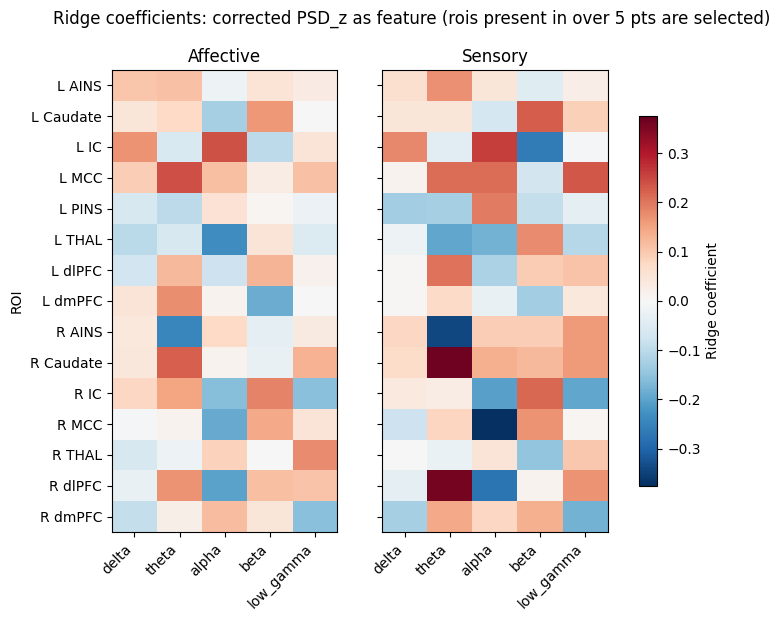

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt


def parse_feat_name(name):
    band = name.split('__', 1)[0]
    roi = name.split('__', 1)[1]
    roi = re.sub(r'_(corrected|raw)_z$', '', roi)
    return band, roi

parsed = coef_df.copy()
parsed[['band', 'roi']] = parsed.index.to_series().apply(lambda n: pd.Series(parse_feat_name(n)))

bands_order = ['delta', 'theta', 'alpha', 'beta', 'low_gamma', 'high_gamma']
bands_present = [b for b in bands_order if b in parsed['band'].unique()]
rois_present = sorted(parsed['roi'].unique())


mat_aff  = parsed.pivot_table(index='roi', columns='band', values='coef_aff').reindex(index=rois_present, columns=bands_present)
mat_sens = parsed.pivot_table(index='roi', columns='band', values='coef_sens').reindex(index=rois_present, columns=bands_present)


max_abs = np.nanmax(np.abs(np.concatenate([mat_aff.values, mat_sens.values])))

fig, axes = plt.subplots(1, 2, figsize=(8, max(4, 0.4*len(rois_present))), sharey=True)

for ax, mat, title in zip(axes, [mat_aff, mat_sens], ['Affective', 'Sensory']):
    im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-max_abs, vmax=max_abs, aspect='auto')
    ax.set_xticks(range(len(bands_present)))
    ax.set_xticklabels(bands_present, rotation=45, ha='right')
    ax.set_title(title)

axes[0].set_yticks(range(len(rois_present)))
axes[0].set_yticklabels(rois_present)
axes[0].set_ylabel('ROI')

fig.colorbar(im, ax=axes, label='Ridge coefficient', shrink=0.8)
fig.suptitle('Ridge coefficients: corrected PSD_z as feature (rois present in over 5 pts are selected)')
plt.show()

In [ ]:
# KFold CV
keep_cols_final = [c for c in feat_df_roi.columns if any(roi in c for roi in rois_only)]
X_df = feat_df_roi[keep_cols_final]
X_df.head()

,alpha__L AINS_corrected_z,alpha__L Caudate_corrected_z,alpha__L IC_corrected_z,alpha__L MCC_corrected_z,alpha__L PINS_corrected_z,alpha__L THAL_corrected_z,alpha__L dlPFC_corrected_z,alpha__L dmPFC_corrected_z,alpha__R AINS_corrected_z,alpha__R Caudate_corrected_z,...,theta__L THAL_raw_z,theta__L dlPFC_raw_z,theta__L dmPFC_raw_z,theta__R AINS_raw_z,theta__R Caudate_raw_z,theta__R IC_raw_z,theta__R MCC_raw_z,theta__R THAL_raw_z,theta__R dlPFC_raw_z,theta__R dmPFC_raw_z
0,-1.971147,NaN,-0.464212,-0.070879,-0.965779,NaN,0.242131,-0.845097,NaN,NaN,...,NaN,4.180416,4.515128,NaN,NaN,3.072854,3.193604,2.859741,NaN,3.915372
1,-2.154493,NaN,0.581104,0.242829,-2.163424,NaN,-0.093830,0.000523,NaN,NaN,...,NaN,0.339641,0.290323,NaN,NaN,-0.402552,0.008432,-0.446679,NaN,0.379105
2,-0.324388,NaN,0.091024,-0.500044,-2.175785,NaN,-0.124342,0.303078,NaN,NaN,...,NaN,0.113314,0.027476,NaN,NaN,-0.437332,-0.276952,-0.446766,NaN,0.302641
3,0.237283,NaN,0.492406,0.381685,-1.133231,NaN,-0.460413,-0.122395,NaN,NaN,...,NaN,0.139157,-0.011775,NaN,NaN,-0.375789,-0.280321,-0.435382,NaN,0.237586
4,0.103299,NaN,-0.120362,-0.142492,-0.815080,NaN,-0.830361,-0.652616,NaN,NaN,...,NaN,0.304401,-0.029497,NaN,NaN,-0.330558,-0.193768,-0.317850,NaN,0.195580


In [ ]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score

feat_cols = [c for c in X_df.columns if c.endswith('_raw_z')]

X_df = X_df[feat_cols].copy()

y_df = feat_df_roi[['aff_score', 'sens_score']].copy()
groups = feat_df_roi['ptID'].values

X = X_df.values
y = y_df.values

ridge_cv = RidgeCV(alphas=[0.1, 0.5, 1, 2, 5, 10, 50, 100])

pipe = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('ridge', ridge_cv)])
kf = KFold(n_splits=10, shuffle=True, random_state=42)

y_pred = cross_val_predict(pipe, X, y, cv=kf)
print('R2 aff:', r2_score(y[:,0], y_pred[:,0]))
print('R2 sens:', r2_score(y[:,1], y_pred[:,1]))

R2 aff: 0.16765455163524945
R2 sens: 0.20808349470060428


In [39]:
imputer_full = SimpleImputer(strategy='mean').fit(X)
X_full_imputed = imputer_full.transform(X)

full_cv = KFold(n_splits=10, shuffle=True, random_state=42)

final_ridge_aff  = RidgeCV(alphas=[0.1, 0.5, 1, 2, 5, 10, 50, 100], cv=full_cv).fit(X_full_imputed, y[:,0])
final_ridge_sens = RidgeCV(alphas=[0.1, 0.5, 1, 2, 5, 10, 50, 100], cv=full_cv).fit(X_full_imputed, y[:,1])

print(f"final alpha_aff: {final_ridge_aff.alpha_}, final alpha_sens: {final_ridge_sens.alpha_}")

coef_df = pd.DataFrame({
    'coef_aff': final_ridge_aff.coef_,
    'coef_sens': final_ridge_sens.coef_,
}, index=X_df.columns)

coef_df

final alpha_aff: 2.0, final alpha_sens: 2.0


,coef_aff,coef_sens
alpha__L AINS_raw_z,-0.142921,-0.218607
alpha__L Caudate_raw_z,-0.501439,-0.841022
alpha__L IC_raw_z,0.433002,0.015822
alpha__L MCC_raw_z,0.292527,0.871226
alpha__L PINS_raw_z,-0.396392,0.442545
...,...,...
theta__R IC_raw_z,0.404320,0.216394
theta__R MCC_raw_z,0.183811,0.491257
theta__R THAL_raw_z,-0.214336,-0.486734
theta__R dlPFC_raw_z,1.000099,1.318826


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr
keep_cols_final = [c for c in feat_df_roi.columns if any(roi in c for roi in rois_only)]
feat_cols = [c for c in keep_cols_final if c.endswith('t_z')]

X_df = feat_df_roi[feat_cols].copy()
X = X_df.values
groups = feat_df_roi['ptID'].values
# y_aff  = feat_df_roi['aff_score'].values
# y_sens = feat_df_roi['sens_score'].values

y_nrs  = feat_df_roi['nrs_z'].values

alphas_grid = [1, 2, 50, 75, 100, 200]
y_bins_nrs  = pd.qcut(y_nrs,  q=3, labels=False, duplicates='drop')
# y_bins_aff  = pd.qcut(y_aff,  q=3, labels=False, duplicates='drop')
# y_bins_sens = pd.qcut(y_sens, q=3, labels=False, duplicates='drop')
def run_nested_cv(X, y, y_bins, alphas_grid, feat_cols, n_splits=10, random_state=42):
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('ridge', RidgeCV(fit_intercept=False, alphas=alphas_grid))
    ])

    y_pred = np.zeros_like(y, dtype=float)
    fold_coefs = []
    fold_alphas = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y_bins)):
        pipe.fit(X[train_idx], y[train_idx])
        y_pred[test_idx] = pipe.predict(X[test_idx])

        fold_coefs.append(pipe.named_steps['ridge'].coef_)
        fold_alphas.append(pipe.named_steps['ridge'].alpha_)

    fold_coefs = np.array(fold_coefs)  # shape: (n_splits, n_features)

    coef_stability_df = pd.DataFrame({
        'feature': feat_cols,
        'mean_coef': fold_coefs.mean(axis=0),
        'std_coef': fold_coefs.std(axis=0),
        'snr': fold_coefs.mean(axis=0) / fold_coefs.std(axis=0),
        'sign_consistency': (np.sign(fold_coefs) == np.sign(fold_coefs.mean(axis=0))).mean(axis=0),
    }).sort_values('snr', key=np.abs, ascending=False)

    return y_pred, fold_coefs, coef_stability_df, fold_alphas

y_pred_nrs  = run_nested_cv(X, y_nrs,  y_bins_nrs,  alphas_grid)
# y_pred_aff  = run_nested_cv(X, y_aff,  y_bins_aff,  alphas_grid)
# y_pred_sens = run_nested_cv(X, y_sens, y_bins_sens, alphas_grid)

def summarize_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    r, p_r     = pearsonr(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"  R2            = {r2:.3f}")
    print(f"  Pearson r     = {r:.3f}  (p={p_r:.4f})")
    return {'R2': r2, 'pearson_r': r, 'pearson_p': p_r}

metrics_nrs  = summarize_metrics(y_nrs,  y_pred_nrs,  'aff_score  (StratifiedKFold)')
y_pred_nrs, fold_coefs_nrs, coef_stability_nrs, fold_alphas_nrs = run_nested_cv(
    X, y_nrs, y_bins_nrs, alphas_grid, feat_cols
)

display(coef_stability_nrs)
# metrics_aff  = summarize_metrics(y_aff,  y_pred_aff,  'aff_score  (StratifiedKFold)')
# metrics_sens = summarize_metrics(y_sens, y_pred_sens, 'sens_score (StratifiedKFold)')

metrics_df = pd.DataFrame(
    {'nrs': metrics_nrs}
    # {'aff': metrics_aff, 'sens': metrics_sens}
    )
display(metrics_df)
imputer_full = SimpleImputer(strategy='mean').fit(X)
X_full_imputed = imputer_full.transform(X)

full_cv_nrs  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_full_imputed, y_bins_nrs)
# full_cv_aff  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_full_imputed, y_bins_aff)
# full_cv_sens = StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_full_imputed, y_bins_sens)

final_ridge_nrs = RidgeCV(fit_intercept=False,alphas=alphas_grid, cv=list(full_cv_nrs)).fit(X_full_imputed, y_nrs)
# final_ridge_aff  = RidgeCV(fit_intercept=False,alphas=alphas_grid, cv=list(full_cv_aff)).fit(X_full_imputed, y_aff)
# final_ridge_sens = RidgeCV(fit_intercept=False,alphas=alphas_grid, cv=list(full_cv_sens)).fit(X_full_imputed, y_sens)

# print(f"final alpha_aff: {final_ridge_aff.alpha_}, final alpha_sens: {final_ridge_sens.alpha_}")

coef_df = pd.DataFrame({
    'coef_nrs': final_ridge_nrs.coef_
    # 'coef_aff':  final_ridge_aff.coef_,
    # 'coef_sens': final_ridge_sens.coef_,
}, index=X_df.columns)

coef_df

--- aff_score  (StratifiedKFold) ---
  R2            = 0.020
  Pearson r     = 0.180  (p=0.0000)


,nrs
R2,0.020039
pearson_r,0.180033
pearson_p,0.000003


,coef_nrs
L AINS_exponent_z,-0.214384
L Caudate_exponent_z,0.151468
L IC_exponent_z,-0.044498
L MCC_exponent_z,0.042658
L PINS_exponent_z,0.018028
L THAL_exponent_z,-0.321703
L dlPFC_exponent_z,0.063691
L dmPFC_exponent_z,0.517078
R AINS_exponent_z,0.134931
R Caudate_exponent_z,0.122643


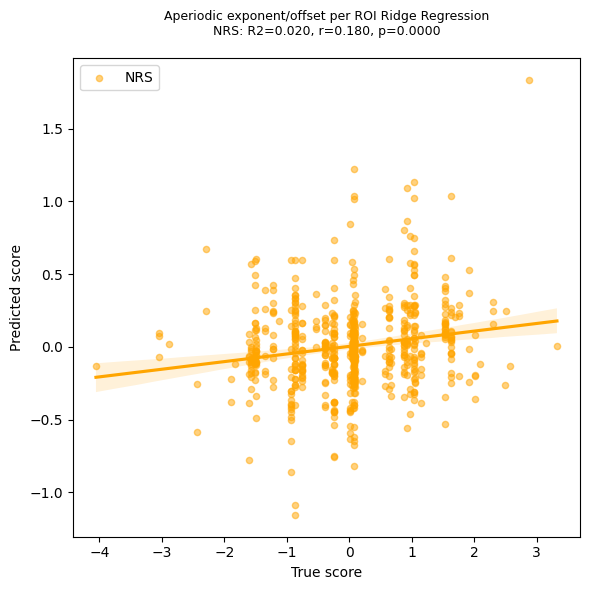

In [41]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    'nrs_true': y_nrs,'nrs_pred': y_pred_nrs
    # 'affective_true': y_aff, 'sensory_true': y_sens,
    # 'affective_pred': y_pred_aff, 'sensory_pred': y_pred_sens
})

fig, ax = plt.subplots(figsize=(6,6))

sns.regplot(data=plot_df, x='nrs_true', y='nrs_pred', color='orange', 
            ax=ax, label='NRS', scatter_kws={'alpha':0.5, 's':20})
# sns.regplot(data=plot_df, x='affective_true', y='affective_pred', color='red', 
#             ax=ax, label='Affective', scatter_kws={'alpha':0.5, 's':20})
# sns.regplot(data=plot_df, x='sensory_true', y='sensory_pred', color='skyblue', 
#             ax=ax, label='Sensory', scatter_kws={'alpha':0.5, 's':20})

ax.set_xlabel('True score')
ax.set_ylabel('Predicted score')
ax.legend()
ax.set_title(
    # f"Corrected PSD Ridge Regression\n"
    f"Aperiodic exponent/offset per ROI Ridge Regression\n"
    f"NRS: R2={metrics_nrs['R2']:.3f}, r={metrics_nrs['pearson_r']:.3f}, p={metrics_nrs['pearson_p']:.4f}\n",
    # f"Affective: R2={metrics_aff['R2']:.3f}, r={metrics_aff['pearson_r']:.3f}, p={metrics_aff['pearson_p']:.4f}\n"
    # f"Sensory:   R2={metrics_sens['R2']:.3f}, r={metrics_sens['pearson_r']:.3f}, p={metrics_sens['pearson_p']:.4f}",
    fontsize=9
)
plt.tight_layout()
plt.show()

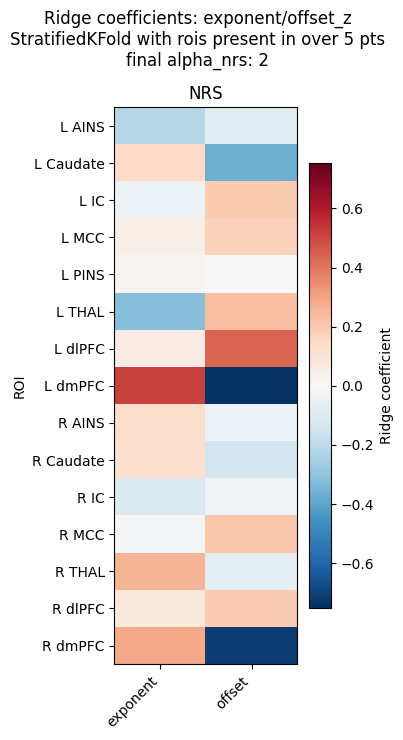

In [44]:
import re

def parse_feat_name(name):
    m = re.match(r'^(.+)_(exponent|offset)_z$', name)
    roi = m.group(1)
    metric = m.group(2)
    return metric, roi

parsed = coef_df.copy()
parsed[['metric', 'roi']] = parsed.index.to_series().apply(lambda n: pd.Series(parse_feat_name(n)))

metrics_order = ['exponent', 'offset']
metrics_present = [m for m in metrics_order if m in parsed['metric'].unique()]
rois_present = sorted(parsed['roi'].unique())

mat_nrs = parsed.pivot_table(index='roi', columns='metric', values='coef_nrs').reindex(index=rois_present, columns=metrics_present)

max_abs = np.nanmax(np.abs(mat_nrs.values))

fig, ax = plt.subplots(figsize=(4, max(5, 0.5*len(rois_present))))

im = ax.imshow(mat_nrs.values, cmap='RdBu_r', vmin=-max_abs, vmax=max_abs, aspect='auto')
ax.set_xticks(range(len(metrics_present)))
ax.set_xticklabels(metrics_present, rotation=45, ha='right')
ax.set_title('NRS')

ax.set_yticks(range(len(rois_present)))
ax.set_yticklabels(rois_present)
ax.set_ylabel('ROI')

fig.colorbar(im, ax=ax, label='Ridge coefficient', shrink=0.8)
fig.suptitle('Ridge coefficients: exponent/offset_z\nStratifiedKFold with rois present in over 5 pts\n'
             f'final alpha_nrs: {final_ridge_nrs.alpha_}')
plt.tight_layout()
plt.show()

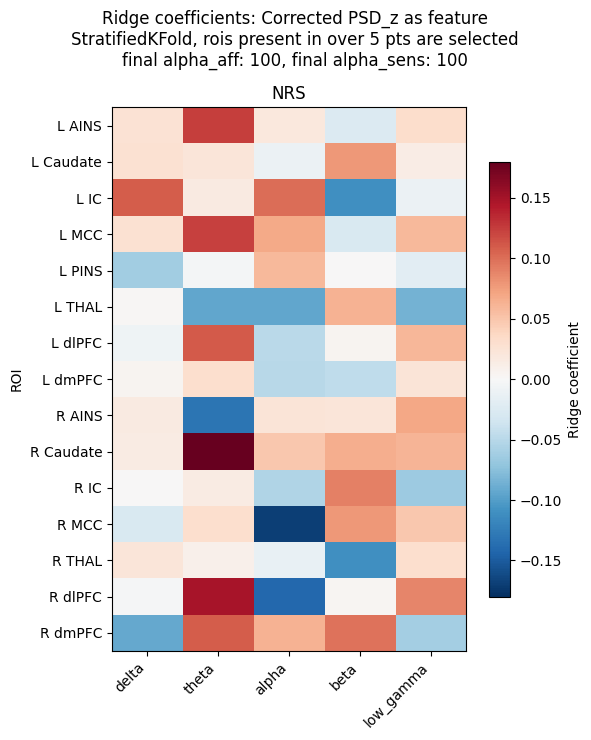

In [17]:
import re

def parse_feat_name(name):
    band = name.split('__', 1)[0]
    roi = name.split('__', 1)[1]
    roi = re.sub(r'_(corrected|raw)_z$', '', roi)
    return band, roi

parsed = coef_df.copy()
parsed[['band', 'roi']] = parsed.index.to_series().apply(lambda n: pd.Series(parse_feat_name(n)))

bands_order = ['delta', 'theta', 'alpha', 'beta', 'low_gamma', 'high_gamma']
bands_present = [b for b in bands_order if b in parsed['band'].unique()]
rois_present = sorted(parsed['roi'].unique())

mat_nrs = parsed.pivot_table(index='roi', columns='band', values='coef_nrs').reindex(index=rois_present, columns=bands_present)
# mat_aff  = parsed.pivot_table(index='roi', columns='band', values='coef_aff').reindex(index=rois_present, columns=bands_present)
# mat_sens = parsed.pivot_table(index='roi', columns='band', values='coef_sens').reindex(index=rois_present, columns=bands_present)


max_abs = np.nanmax(np.abs(mat_nrs.values))

fig, ax = plt.subplots(figsize=(6, max(5, 0.5*len(rois_present))))

im = ax.imshow(mat_nrs.values, cmap='RdBu_r', vmin=-max_abs, vmax=max_abs, aspect='auto')
ax.set_xticks(range(len(bands_present)))
ax.set_xticklabels(bands_present, rotation=45, ha='right')
ax.set_title('NRS')

ax.set_yticks(range(len(rois_present)))
ax.set_yticklabels(rois_present)
ax.set_ylabel('ROI')

# max_abs = np.nanmax(np.abs(np.concatenate([mat_aff.values, mat_sens.values])))

# fig, axes = plt.subplots(1, 2, figsize=(8, max(4, 0.4*len(rois_present))), sharey=True)

# for ax, mat, title in zip(axes, [mat_aff, mat_sens], ['Affective', 'Sensory']):
#     im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-max_abs, vmax=max_abs, aspect='auto')
#     ax.set_xticks(range(len(bands_present)))
#     ax.set_xticklabels(bands_present, rotation=45, ha='right')
#     ax.set_title(title)

# axes[0].set_yticks(range(len(rois_present)))
# axes[0].set_yticklabels(rois_present)
# axes[0].set_ylabel('ROI')

fig.colorbar(im, ax=ax, label='Ridge coefficient', shrink=0.8)
fig.suptitle(f'Ridge coefficients: Corrected PSD_z as feature\nStratifiedKFold, rois present in over 5 pts are selected\nfinal alpha_aff: {final_ridge_nrs.alpha_}, final alpha_sens: {final_ridge_nrs.alpha_}')
plt.tight_layout()
plt.show()

In [5]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

def run_stratified_cv(X, y_aff, y_sens, n_splits, q, alphas_grid, random_state=42):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_alphas_aff, fold_alphas_sens = [], []
    y_pred_aff = np.full(len(y_aff), np.nan)
    y_pred_sens = np.full(len(y_sens), np.nan)

    y_bins_aff = pd.qcut(y_aff, q=q, labels=False, duplicates='drop')
    y_bins_sens = pd.qcut(y_sens, q=q, labels=False, duplicates='drop')

    for train_idx, test_idx in skf.split(X, y_bins_aff):
        imputer = SimpleImputer(strategy='mean').fit(X[train_idx])
        X_train, X_test = imputer.transform(X[train_idx]), imputer.transform(X[test_idx])
        m = RidgeCV(alphas=alphas_grid).fit(X_train, y_aff[train_idx])
        y_pred_aff[test_idx] = m.predict(X_test)
        fold_alphas_aff.append(m.alpha_)

    for train_idx, test_idx in skf.split(X, y_bins_sens):
        imputer = SimpleImputer(strategy='mean').fit(X[train_idx])
        X_train, X_test = imputer.transform(X[train_idx]), imputer.transform(X[test_idx])
        m = RidgeCV(alphas=alphas_grid).fit(X_train, y_sens[train_idx])
        y_pred_sens[test_idx] = m.predict(X_test)
        fold_alphas_sens.append(m.alpha_)

    return {
        'n_splits': n_splits,
        'q': q,
        'r2_aff': r2_score(y_aff, y_pred_aff),
        'r2_sens': r2_score(y_sens, y_pred_sens),
        'alphas_aff': fold_alphas_aff,
        'alphas_sens': fold_alphas_sens,
        'alpha_aff_mode': pd.Series(fold_alphas_aff).mode()[0],
        'alpha_sens_mode': pd.Series(fold_alphas_sens).mode()[0],
    }
keep_cols_final = [c for c in feat_df_roi.columns if any(roi in c for roi in rois_only)]
X_df = feat_df_roi[keep_cols_final]
feat_cols = [c for c in X_df.columns if c.endswith('_corrected_z')]
X_df = X_df[feat_cols].copy()

groups = feat_df_roi['ptID'].values
X = X_df.values

alphas_grid = [0.1, 0.5, 1, 2, 5, 10, 20, 50, 75, 100]
n_splits_options = [3, 5, 8, 10]
q_options = [2, 3, 4, 5]
# alphas_grid = [75, 100, 150, 200]
# n_splits_options = [5, 10]
# q_options = [2, 3, 4, 5]

y_aff = feat_df_roi['aff_score'].values
y_sens = feat_df_roi['sens_score'].values

sweep_results = []
for n_splits in n_splits_options:
    for q in q_options:
        res = run_stratified_cv(X, y_aff, y_sens, n_splits, q, alphas_grid)
        sweep_results.append(res)

sweep_df = pd.DataFrame(sweep_results)
sweep_df[['n_splits','q','r2_aff','r2_sens','alpha_aff_mode','alpha_sens_mode']]

,n_splits,q,r2_aff,r2_sens,alpha_aff_mode,alpha_sens_mode
0,5,2,0.106523,0.141244,100,75
1,5,3,0.094709,0.137664,100,75
2,5,4,0.117092,0.157306,100,75
3,5,5,0.117689,0.151421,100,75
4,10,2,0.124620,0.139065,100,75
5,10,3,0.111498,0.156661,100,75
6,10,4,0.113782,0.142653,75,75
7,10,5,0.129203,0.149652,75,75


In [48]:
import numpy as np
from scipy.stats import zscore

def behavioral_pls_permutation(
    X,
    Y,
    n_perm=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    # ---------- standardize ----------
    X = zscore(X, axis=0, nan_policy="omit")
    Y = zscore(Y, axis=0, nan_policy="omit")

    X = np.nan_to_num(X)
    Y = np.nan_to_num(Y)

    # ---------- real SVD ----------
    R = X.T @ Y

    U, s, Vt = np.linalg.svd(R, full_matrices=False)

    n_lv = len(s)

    # ---------- permutation ----------
    null_s = np.zeros((n_perm, n_lv))

    for i in range(n_perm):

        idx = rng.permutation(X.shape[0])

        Y_perm = Y[idx]

        R_perm = X.T @ Y_perm

        _, s_perm, _ = np.linalg.svd(
            R_perm,
            full_matrices=False
        )

        null_s[i] = s_perm

    p = np.mean(
        null_s >= s,
        axis=0
    )

    return U, Vt.T, s, p, null_s

In [11]:
keep_cols_final = [c for c in feat_df_roi.columns if any(roi in c for roi in rois_only)]
X_df = feat_df_roi[keep_cols_final]
feat_cols = [c for c in X_df.columns if c.endswith('_corrected_z')]
X_df = X_df[feat_cols].copy()
X_imputed = SimpleImputer(strategy='mean').fit_transform(X_df.values)
Y = feat_df_roi[['aff_score','sens_score']].values

brain_saliences, behavior_saliences, singular_values, pvals, null = behavioral_pls_permutation(X_imputed,Y,n_perm=1000)
print(singular_values)
print(pvals)
print(behavior_saliences)

[619.6923165  123.36356011]
[0.    0.328]
[[-0.73015924  0.68327702]
 [-0.68327702 -0.73015924]]


In [ ]:
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients.csv')
behavior_table

,ptID,trial_idx,nrs_raw,vasp_raw,somatic_raw,unpleasantness_raw,affective_raw,vasd_raw,nrs_z,vasp_z,somatic_z,unpleasantness_z,affective_z,vasd_r_z,pca_sensory_PC1,pca_affective_PC1
0,RCS02,32,3.0,38.0,6.0,50.0,1.0,59.0,-1.572153,-2.331655,-1.537004,-0.944105,-0.653720,0.857070,-3.148555,-0.184285
1,RCS02,33,5.0,52.0,7.0,63.0,1.0,68.0,0.060467,-0.731112,-1.256605,0.075528,-0.653720,-0.353790,-1.063422,-0.692122
2,RCS02,34,5.0,57.0,8.0,70.0,2.0,60.0,0.060467,-0.159490,-0.976205,0.624562,-0.065372,0.722530,-0.576758,0.541736
3,RCS02,35,5.0,60.0,9.0,54.0,11.0,40.0,0.060467,0.183484,-0.695806,-0.630372,5.229764,3.413329,-0.225095,5.890015
4,RCS02,36,6.0,57.0,15.0,54.0,0.0,55.0,0.876777,-0.159490,0.986590,-0.630372,-1.242069,1.395229,0.962826,-0.222151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,RCS09,145,5.0,49.0,14.0,35.0,NaN,NaN,0.095929,0.044711,-0.084711,0.050901,NaN,NaN,0.033547,0.050901
663,RCS09,146,5.0,50.0,14.0,35.0,NaN,NaN,0.095929,0.086111,-0.084711,0.050901,NaN,NaN,0.057536,0.050901
664,RCS09,147,4.0,36.0,6.0,8.0,NaN,NaN,-0.383718,-0.493481,-1.017309,-1.034102,NaN,NaN,-1.089186,-1.034102
665,RCS09,148,3.0,31.0,5.0,6.0,NaN,NaN,-0.863365,-0.700478,-1.133884,-1.114473,NaN,NaN,-1.555070,-1.114473


In [9]:
from sklearn.decomposition import PCA
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06','RCS07', 'RCS08', 'RCS09']
for ptID in ptIDs:
    subset = behavior_table[behavior_table['ptID']==ptID]
    idx = behavior_table['ptID']==ptID
    if ptID == 'RCS09':
        X_affective = np.stack([subset['unpleasantness_z']], axis=1)
        affective_latent = subset['unpleasantness_z'].copy()
    else:
        X_affective = np.stack([
            subset['unpleasantness_z'],
            subset['affective_z']
        ], axis=1)
        affective_pca = PCA(n_components=1)
        affective_latent = affective_pca.fit_transform(X_affective).ravel()

    X_sensory = np.stack([subset['vasp_z'],subset['somatic_z']], axis=1)
    sensory_pca = PCA(n_components=1)
    sensory_latent = sensory_pca.fit_transform(X_sensory).ravel()
    behavior_table.loc[idx,'new_affective_PC1'] = affective_latent
    behavior_table.loc[idx,'new_sensory_PC1'] = sensory_latent

behavior_table.to_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')

behavior_table

,Unnamed: 0,ptID,trial_idx,nrs_raw,vasp_raw,somatic_raw,unpleasantness_raw,affective_raw,vasd_raw,nrs_z,vasp_z,somatic_z,unpleasantness_z,affective_z,vasd_r_z,pca_sensory_PC1,pca_affective_PC1,new_affective_PC1,new_sensory_PC1
0,0,RCS02,32,3.0,38.0,6.0,50.0,1.0,59.0,-1.572153,-2.331655,-1.537004,-0.944105,-0.653720,0.857070,-3.148555,-0.184285,-1.129834,-2.735555
1,1,RCS02,33,5.0,52.0,7.0,63.0,1.0,68.0,0.060467,-0.731112,-1.256605,0.075528,-0.653720,-0.353790,-1.063422,-0.692122,-0.408843,-1.405528
2,2,RCS02,34,5.0,57.0,8.0,70.0,2.0,60.0,0.060467,-0.159490,-0.976205,0.624562,-0.065372,0.722530,-0.576758,0.541736,0.395407,-0.803058
3,3,RCS02,35,5.0,60.0,9.0,54.0,11.0,40.0,0.060467,0.183484,-0.695806,-0.630372,5.229764,3.413329,-0.225095,5.890015,3.252261,-0.362266
4,4,RCS02,36,6.0,57.0,15.0,54.0,0.0,55.0,0.876777,-0.159490,0.986590,-0.630372,-1.242069,1.395229,0.962826,-0.222151,-1.324016,0.584849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,662,RCS09,145,5.0,49.0,14.0,35.0,NaN,NaN,0.095929,0.044711,-0.084711,0.050901,NaN,NaN,0.033547,0.050901,0.050901,-0.028284
663,663,RCS09,146,5.0,50.0,14.0,35.0,NaN,NaN,0.095929,0.086111,-0.084711,0.050901,NaN,NaN,0.057536,0.050901,0.050901,0.000990
664,664,RCS09,147,4.0,36.0,6.0,8.0,NaN,NaN,-0.383718,-0.493481,-1.017309,-1.034102,NaN,NaN,-1.089186,-1.034102,-1.034102,-1.068290
665,665,RCS09,148,3.0,31.0,5.0,6.0,NaN,NaN,-0.863365,-0.700478,-1.133884,-1.114473,NaN,NaN,-1.555070,-1.114473,-1.114473,-1.297090


In [65]:
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')
merged = feat_df_roi.merge(behavior_table, on=['ptID','trial_idx'],how='left')
# merged_filt = merged[merged['ptID']!='RCS09']
merged_filt = feat_df_roi

keep_cols_final = [c for c in merged_filt.columns if any(roi in c for roi in rois_only)]
X_df = merged_filt[keep_cols_final]
feat_cols = [c for c in X_df.columns if c.endswith('corrected_z')]
X_df = X_df[feat_cols].copy()
X_imputed = SimpleImputer(strategy='mean').fit_transform(X_df.values)
# Y = feat_df_roi[['aff_score','sens_score']].values
Y = feat_df_roi[['new_affective_PC1','new_sensory_PC1']].values
# Y = merged_filt[['affective_z','somatic_z']].values

brain_saliences, behavior_saliences, singular_values, pvals, null = behavioral_pls_permutation(X_imputed,Y,n_perm=1000)
print(singular_values)
print(pvals)
print(behavior_saliences)

[600.43088451 133.32191087]
[0.    0.208]
[[-0.7110359 -0.7031557]
 [-0.7031557  0.7110359]]


In [66]:
def behavioral_pls_bootstrap(
    X,
    Y,
    n_boot=500,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    # ---------- Original ----------
    R = (X.T @ Y) / (X.shape[0]-1)

    U, s, Vt = np.linalg.svd(R, full_matrices=False)

    original_weights = U[:, 0]      # LV1 only

    n_features = X.shape[1]

    boot_weights = np.zeros((n_boot, n_features))

    # ---------- Bootstrap ----------
    for b in range(n_boot):

        idx = rng.choice(
            X.shape[0],
            size=X.shape[0],
            replace=True
        )

        Xb = X[idx]
        Yb = Y[idx]

        Rb = (Xb.T @ Yb) / (Xb.shape[0]-1)

        Ub, sb, Vtb = np.linalg.svd(
            Rb,
            full_matrices=False
        )

        # ---------- Sign alignment ----------
        if np.dot(Ub[:,0], original_weights) < 0:
            Ub[:,0] *= -1

        boot_weights[b] = Ub[:,0]

    # ---------- Bootstrap ratio ----------
    boot_sd = boot_weights.std(axis=0, ddof=1)

    bsr = original_weights / boot_sd

    result = pd.DataFrame({
        "Weight": original_weights,
        "Bootstrap_SD": boot_sd,
        "BSR": bsr,
        "Reliable": np.abs(bsr) >= 2.57
    })

    return result

bsr_df = behavioral_pls_bootstrap(X_imputed,Y,n_boot=2000)
bsr_df.index = X_df.columns
bsr_df

,Weight,Bootstrap_SD,BSR,Reliable
alpha__L AINS_corrected_z,-0.114811,0.065760,-1.745916,False
alpha__L Caudate_corrected_z,-0.038288,0.053834,-0.711220,False
alpha__L IC_corrected_z,-0.188404,0.055686,-3.383320,True
alpha__L MCC_corrected_z,-0.144365,0.064566,-2.235933,False
alpha__L PINS_corrected_z,-0.159134,0.059198,-2.688194,True
...,...,...,...,...
theta__R IC_corrected_z,-0.061561,0.033799,-1.821383,False
theta__R MCC_corrected_z,0.028929,0.065450,0.442003,False
theta__R THAL_corrected_z,-0.049277,0.053148,-0.927165,False
theta__R dlPFC_corrected_z,-0.207167,0.045322,-4.570957,True


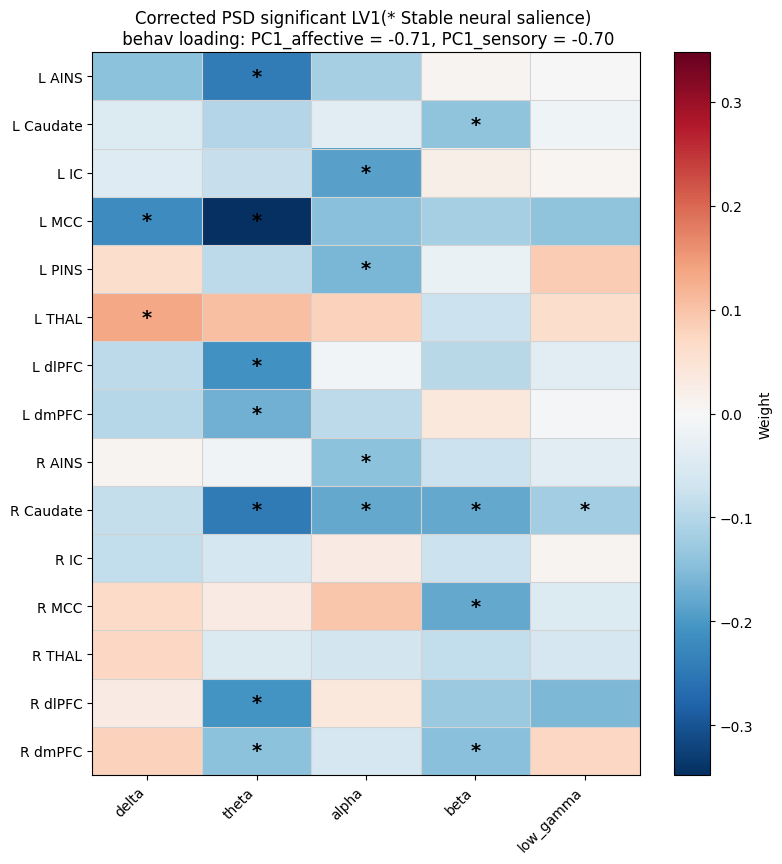

In [67]:
import re
from matplotlib.colors import TwoSlopeNorm
def parse_feat_name(name):
    band = name.split('__', 1)[0]
    roi = name.split('__', 1)[1]
    roi = re.sub(r'_(corrected|raw)_z$', '', roi)
    return band, roi

parsed = bsr_df.copy()
parsed[['band', 'roi']] = parsed.index.to_series().apply(lambda n: pd.Series(parse_feat_name(n)))

bands_order = ['delta', 'theta', 'alpha', 'beta', 'low_gamma', 'high_gamma']
bands_present = [b for b in bands_order if b in parsed['band'].unique()]
rois_present = sorted(parsed['roi'].unique())

# def parse_feat_name(name):
#     m = re.match(r'^(.+)_(exponent|offset)_z$', name)
#     roi = m.group(1)
#     metric = m.group(2)
#     return metric, roi

# parsed = bsr_df.copy()
# parsed[['metric', 'roi']] = parsed.index.to_series().apply(lambda n: pd.Series(parse_feat_name(n)))
# metrics_order = ['exponent', 'offset']
# metrics_present = [m for m in metrics_order if m in parsed['metric'].unique()]
# rois_present = sorted(parsed['roi'].unique())


mat_weight = (
    parsed.pivot_table(index='roi', columns='band', values='Weight')
    .reindex(index=rois_present, columns=bands_present)
)

# significance matrix
mat_sig = (
    parsed.pivot_table(index='roi', columns='band', values='Reliable')
    .reindex(index=rois_present, columns=bands_present)
)

vmax = np.nanmax(np.abs(mat_weight.values))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(1.2*len(bands_present)+2,
                                0.45*len(rois_present)+2))
im = ax.imshow(
    mat_weight,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    aspect="auto"
)

for i in range(mat_weight.shape[0]):
    for j in range(mat_weight.shape[1]):
        if pd.isna(mat_weight.iat[i, j]):
            continue

        if bool(mat_sig.iat[i, j]):
            ax.text(
                j, i, '*',
                ha='center',
                va='center',
                fontsize=14,
                color='black',
                fontweight='bold'
            )

# ticks
ax.set_xticks(np.arange(len(bands_present)))
ax.set_xticklabels(bands_present, rotation=45, ha='right')

ax.set_yticks(np.arange(len(rois_present)))
ax.set_yticklabels(rois_present)

# grid
ax.set_xticks(np.arange(-0.5, len(bands_present), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(rois_present), 1), minor=True)
ax.grid(which='minor', color='lightgray', linewidth=0.8)
ax.tick_params(which='minor', length=0)

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Weight")

ax.set_title("Corrected PSD significant LV1(* Stable neural salience) \n behav loading: PC1_affective = -0.71, PC1_sensory = -0.70")
# ax.set_title("Aperiodic exponent/offset significant LV1(* Stable neural salience) \n behav loading: PC1_affective = -0.74, PC1_sensory = -0.67")

plt.tight_layout()
plt.show()

Text(0.5, 1.08, 'Corrected PSD significant LV1\nbehav loading: PC1_affective = -0.71, PC1_sensory = -0.70\nr = 0.385, r² = 0.148, p = 0.0000')

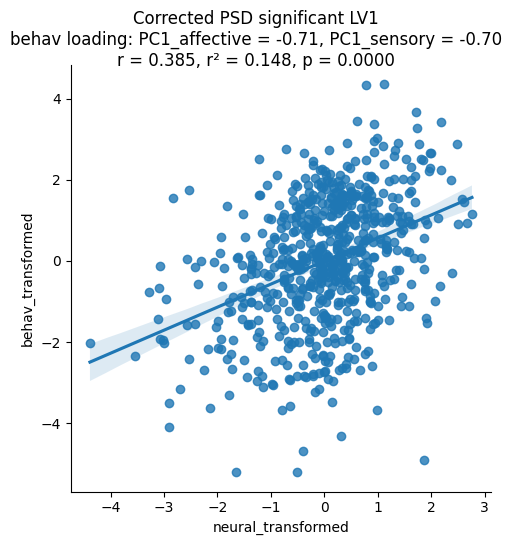

In [68]:
brain_score = X_imputed @ brain_saliences[:,0]

behavior_score = Y @ behavior_saliences[:,0]
from scipy.stats import pearsonr

r, p = pearsonr(brain_score, behavior_score)
r2 = r**2

plot_df = pd.DataFrame({'neural_transformed': brain_score, 'behav_transformed': behavior_score})

g = sns.lmplot(
    data=plot_df, x='neural_transformed', y='behav_transformed', fit_reg=True
)
g.fig.suptitle(
    f"Corrected PSD significant LV1\n"
    # f"Aperiodic exponent/offset significant LV1\n"
    f"behav loading: PC1_affective = -0.71, PC1_sensory = -0.70\n"
    # f"behav loading: PC1_affective = -0.74, PC1_sensory = -0.67\n"
    f"r = {r:.3f}, r² = {r2:.3f}, p = {p:.4f}",
    y=1.08
)